In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from ydata_profiling import ProfileReport
from sklearn.linear_model import LogisticRegression

In [23]:
df=pd.read_csv("diabetes.csv")

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [25]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [26]:
df.eq(0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [27]:
X=df.drop(columns=["Outcome"])
y=df["Outcome"]

In [28]:
X.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
544,1,88,78,29,76,32.0,0.365,29
153,1,153,82,42,485,40.6,0.687,23
644,3,103,72,30,152,27.6,0.730,27
518,13,76,60,0,0,32.8,0.180,41
297,0,126,84,29,215,30.7,0.520,24


In [29]:
X.replace(0,np.nan,inplace=True)

In [30]:
X.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,657.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000
mean,4.494673,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885
std,3.217291,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232
min,1.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000
25%,2.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000
50%,4.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000
75%,7.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [31]:
X_trf=X.copy()

In [ ]:
trf1=ColumnTransformer(
    transformers=[
        ("transformed_pregnancies",PowerTransformer(method='yeo-johnson', standardize=True),[0]),
        ("transformed_insulin",PowerTransformer(method='yeo-johnson', standardize=True),[4]),
        ("transformed_dbfunction",PowerTransformer(method='yeo-johnson', standardize=True),[6])
    ],remainder='passthrough'
)

In [36]:
trf2=ColumnTransformer(
    transformers=[
        ("imputed_data",SimpleImputer(),list(range(X_trf.shape[1])))
    ],remainder='passthrough'
)

In [37]:
X_trf=pd.DataFrame(trf1.fit_transform(X_trf))
X_trf=pd.DataFrame(trf2.fit_transform(X_trf))

In [38]:
X_trf.isna().sum()

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
dtype: int64

In [39]:
X_trf

,0,1,2,3,4,5,6,7
0,0.904728,6.149382e-01,0.000994,50.0,0.821764,7.014455e-01,72.0,33.6
1,-1.301255,6.875761e-02,0.000994,31.0,-0.168409,-1.421508e+00,66.0,26.6
2,1.779693,-8.701193e-17,0.000994,32.0,0.935284,1.118200e+00,64.0,23.3
3,-1.122709,-5.320185e-01,-0.550879,21.0,-1.298725,-1.421508e+00,66.0,28.1
4,0.590601,6.149382e-01,0.615702,33.0,2.336680,2.217066e-16,40.0,43.1
...,...,...,...,...,...,...,...,...
763,-0.627528,1.666887e+00,0.756180,63.0,-1.267837,1.448817e+00,76.0,32.9
764,0.123158,-1.246023e-01,0.000994,27.0,-0.222191,-7.260166e-01,70.0,36.8
765,0.090172,-5.320185e-01,-0.201889,30.0,-0.753116,4.443243e-01,72.0,26.2
766,0.252698,-8.701193e-17,0.000994,47.0,-0.178081,-1.421508e+00,60.0,30.1


In [40]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21
4,NaN,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63
764,2.0,122.0,70.0,27.0,NaN,36.8,0.340,27
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30
766,1.0,126.0,60.0,NaN,NaN,30.1,0.349,47


In [41]:
X.isna().sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

C:\Users\umair\AppData\Local\Temp\ipykernel_5160\3489350555.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_trf[0],hist=False)


<Axes: xlabel='0', ylabel='Density'>

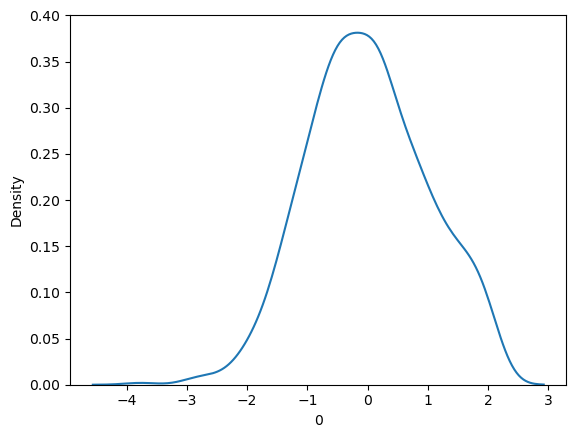

In [42]:
# sns.distplot(X["Insulin"],hist=False)
sns.distplot(X_trf[0],hist=False)

In [ ]:
X["Insulin"]=X_trf[0]
X["DiabetesPedigreeFunction"]=X_trf[1]
X["Pregnancies"]=X_trf[2]
X["BloodPressure"]=X_trf[6]


In [44]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.000994,148.0,72.0,35.0,0.904728,33.6,6.149382e-01,50
1,0.000994,85.0,66.0,29.0,-1.301255,26.6,6.875761e-02,31
2,0.000994,183.0,64.0,NaN,1.779693,23.3,-8.701193e-17,32
3,-0.550879,89.0,66.0,23.0,-1.122709,28.1,-5.320185e-01,21
4,0.615702,137.0,40.0,35.0,0.590601,43.1,6.149382e-01,33
...,...,...,...,...,...,...,...,...
763,0.756180,101.0,76.0,48.0,-0.627528,32.9,1.666887e+00,63
764,0.000994,122.0,70.0,27.0,0.123158,36.8,-1.246023e-01,27
765,-0.201889,121.0,72.0,23.0,0.090172,26.2,-5.320185e-01,30
766,0.000994,126.0,60.0,NaN,0.252698,30.1,-8.701193e-17,47


In [45]:
X.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                       0
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64